# CF Methods Benchmark — Analysis Notebook

Loads the results DataFrame produced by `tabpfn_cf5.ipynb` and runs five sections of analysis.  
Set `data_in = "real"` or `"mock"` in cell 0 to switch between result files.

| Method | Sparsity objective? | Notes |
|---|---|---|
| `pace` (guided) | ✓ anchor-based | our method |
| `nice_spars` | ✓ explicit | NICE with `optimization='sparsity'` |
| `nice_base` | ✗ | NICE nearest-neighbour, no sparsity |
| `dice` | partial | genetic: `sparsity_weight=1.0`; random: none |
| `mcce` | selection only | picks lowest L0 among samples; effective only when immutables anchor most features |

In [170]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import FixedLocator, FuncFormatter
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from scipy.stats import binomtest

#df = joblib.load("results_df_all.joblib")
data_in = "real" # real or mock
#df = joblib.load("output_"+data_in+"data_times_with_tabpfn.joblib")
#df = joblib.load("output_mockdata.joblib")
df = joblib.load("output_realdata.joblib")
print("Number of", data_in, "datasets:",len(df.dataset.unique()))

Number of real datasets: 7


In [171]:
def export_table_to_latex(df: pd.DataFrame, filename: str) -> None:
    df2 = df.copy()

    # 1) Escape underscores in dataset names only (safe even if dataset isn't string)
    if "dataset" in df2.columns:
        df2["dataset"] = df2["dataset"].astype(str).str.replace("_", r"\_", regex=False)

    # 2) Column renaming map: apply only for columns that exist
    rename_map = {
        # Wilcoxon-style table
        "l0": r"$\ell_0$",
        "median_delta_l2_A_minus_B": r"$\mathrm{median}\,\Delta\ell_2^{A-B}$",
        "wilcoxon_stat": r"$W$",
        "p_value": r"$p$-value",
        "ci_lo": r"CI$_{lo}$",
        "ci_hi": r"CI$_{hi}$",

        # Pareto / dominance-style table
        "method_a":"method A",
        "method_b":"method B",
        "n_paired": r"$n_{\mathrm{paired}}$",
        "n_A_dom": r"$n_{A\succ B}$",
        "n_B_dom": r"$n_{B\succ A}$",
        "n_equal": r"$n_{A = B}$",
        "n_incomparable": r"$n_{\parallel}$",
        "rate_A_dom": r"$\mathrm{rate}_{A\succ B}$",
        "rate_B_dom": r"$\mathrm{rate}_{B\succ A}$",
        "rate_equal": r"$\mathrm{rate}_{A = B}$",
        "rate_incomparable": r"$\mathrm{rate}_{\parallel}$",
    }

    df2 = df2.rename(columns={k: v for k, v in rename_map.items() if k in df2.columns})

    # 3) Choose float formatting: if "rate_" columns exist, show as 3 decimals (or % if you prefer)
    has_rates = any(c.startswith("rate_") for c in df.columns)
    float_format = (lambda x: f"{x:.3f}") if has_rates else "%.3g"

    # 4) Auto column_format: l for text-ish columns, r for numeric-ish
    #    (pandas types can be messy; this heuristic works well)
    col_format = ""
    for col in df2.columns:
        # treat these as text columns
        if col in ["dataset", "model", "method", "method_a", "method_b"] or df2[col].dtype == "object":
            col_format += "l"
        else:
            col_format += "r"

    latex_code = df2.to_latex(
        index=False,
        escape=False,          # keep math in headers
        float_format=float_format,
        column_format=col_format
    )

    with open(filename, "w", encoding="utf-8") as f:
        f.write(latex_code)

    print(f"LaTeX table written to {filename}")

In [172]:
COLORS = {
    "nice_base":   "#0072B2",  # blue
    "nice_spars": "#E69F00",  # orange
    "dice":   "#D55E00",  # vermillion
    "mcce": "#CC79A7",  # reddish purple
    "pace": "#009E73",  # bluish green  (your method)
}
methods  = ["dice", "nice_base", "nice_spars", "mcce", "pace"]
models   = ["LR", "RF", "XGB", "TabPFN"] #sorted(df["model"].unique())

## 1. Timing

Box plot of wall-clock time (seconds) per CF, grouped by model and method.  
Assesses computational cost independently of CF quality.

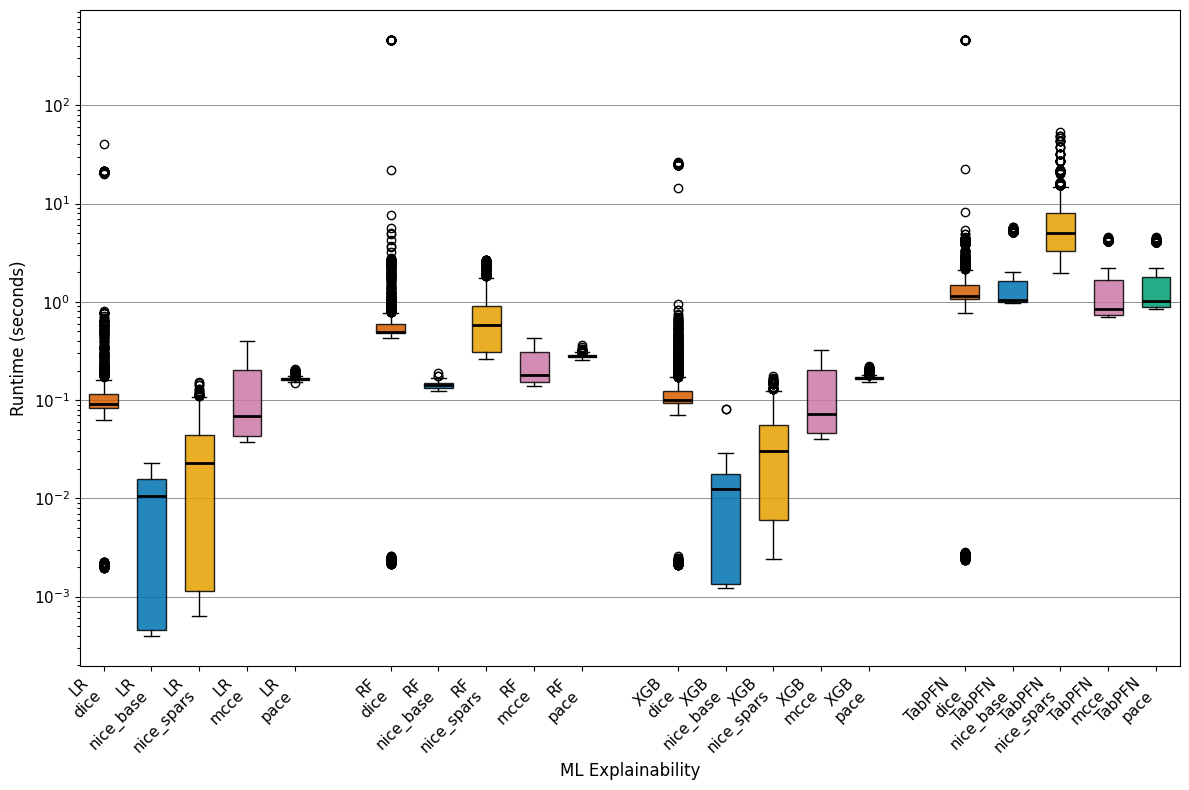

In [173]:
fig, ax = plt.subplots(figsize=(12,8))

positions = []
data = []
colors = []
labels = []

pos = 1
gap = 1

for m in models:
    for method in methods:
        vals = df[(df["model"] == m) & (df["method"] == method)]["time_s"].values
        data.append(vals)
        positions.append(pos)
        labels.append(f"{m}\n{method}")
        colors.append(COLORS[method])
        pos += 1
    pos += gap

bp = ax.boxplot(data, positions=positions, widths=0.6,
                patch_artist=True, showfliers=True)

for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2.0)

for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)

    ax.set_yscale("log")

# Thicker, darker axes
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("black")

# Labels with larger font
ax.set_ylabel("Runtime (seconds)", fontsize=12)
ax.set_xlabel("ML Explainability", fontsize=12)

# Ticks and tick labels
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis='both', which='both', width=0.8, labelsize=11)

# Grid: dark enough, no gray background
ax.grid(True, axis="y", linewidth=0.5, alpha=0.6, color="black")

# Make sure the figure background is white
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Tight layout and save
fig.tight_layout()
fig.savefig(data_in + "data_times.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()

## 2. Flip Success Rate and (ℓ₀, ℓ₂) Trade-off

**(A) Flip success rate** — fraction of factuals for which each method found a valid CF (one that flips the model prediction).

**(B) ℓ₀ vs ℓ₂ scatter** — joint view of sparsity (number of features changed, discrete) against Euclidean distance in the preprocessed space.  
Points are offset horizontally per method so each method occupies its own column at every integer ℓ₀ value.  
Methods without a sparsity objective (`dice`-random, `nice_base`, `mcce` on all-mutable data) tend to change all features and appear at ℓ₀ = total features.

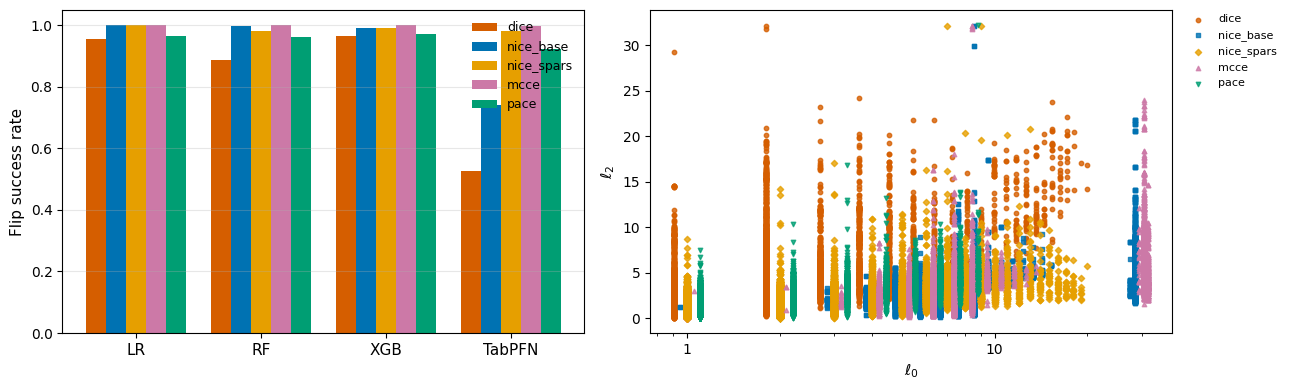

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

datasets = sorted(df["dataset"].unique())

# one marker shape per method
method_markers = ["o", "s", "D", "^", "v"]
method_marker_map = {m: method_markers[i % len(method_markers)] for i, m in enumerate(methods)}

# -------------------------
# (A) BAR PLOT: flip success rate — same for real and mock
# -------------------------
rate = df.groupby(["model", "method"], as_index=False)["flip_ok"].mean()

x = np.arange(len(models))
width = 0.8 / max(1, len(methods))

for i, method in enumerate(methods):
    vals = []
    for m in models:
        sub = rate[(rate["model"] == m) & (rate["method"] == method)]
        vals.append(float(sub["flip_ok"].iloc[0]) if not sub.empty else 0.0)
    offset = (i - (len(methods) - 1) / 2) * width
    axes[0].bar(x + offset, vals, width, color=COLORS[method], label=method)

axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Flip success rate", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_facecolor("white")

# -------------------------
# (B) SCATTER: l0 vs l2 — all models, all datasets; marker = method
# -------------------------
_log_offsets = np.linspace(-0.1, 0.1, len(methods))
_method_offset = {m: _log_offsets[i] for i, m in enumerate(methods)}

for method in methods:
    x_mult = np.exp(_method_offset[method])
    sub_m = df[df["method"] == method]
    axes[1].scatter(
        sub_m["l0"].values * x_mult,
        sub_m["l2"].values,
        color=COLORS[method],
        marker=method_marker_map[method],
        s=10,
        alpha=0.8,
        label=method,
    )

axes[1].legend(
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)

axes[1].set_xlabel(r"$\ell_0$", fontsize=11)
axes[1].set_ylabel(r"$\ell_2$", fontsize=11)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_locator(LogLocator(base=10))
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].set_facecolor("white")

fig.patch.set_facecolor("white")
fig.tight_layout()
fig.savefig(f"{data_in}_flip_l2_l0.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()


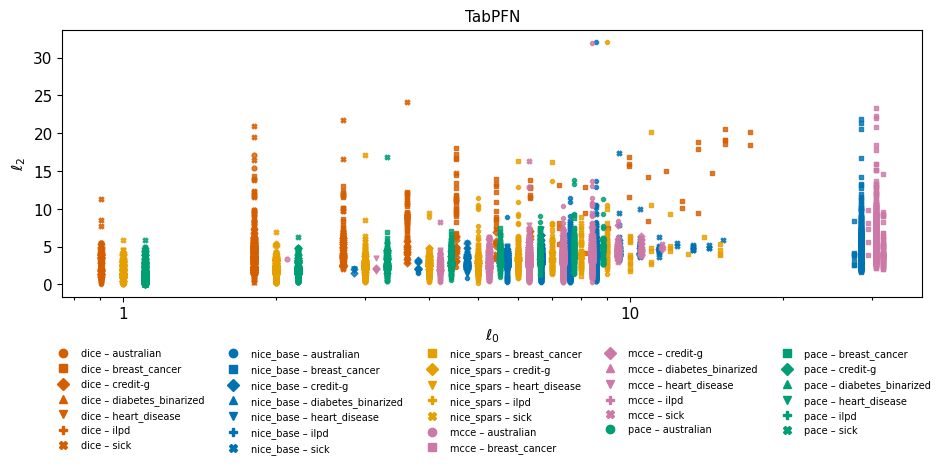

In [175]:
# l0 vs l2 scatter — TabPFN only, split by dataset
datasets = sorted(df["dataset"].unique())
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
marker_map = {ds: markers[i % len(markers)] for i, ds in enumerate(datasets)}

_log_offsets = np.linspace(-0.1, 0.1, len(methods))
_method_offset = {m: _log_offsets[i] for i, m in enumerate(methods)}

tabpfn_df = df[df["model"] == "TabPFN"]
present = set(zip(tabpfn_df["method"], tabpfn_df["dataset"]))

fig, ax = plt.subplots(figsize=(10, 5))
for method in methods:
    x_mult = np.exp(_method_offset[method])
    sub_m = tabpfn_df[tabpfn_df["method"] == method]
    for ds in datasets:
        sub = sub_m[sub_m["dataset"] == ds]
        if sub.empty:
            continue
        ax.scatter(
            sub["l0"].values * x_mult,
            sub["l2"].values,
            color=COLORS[method],
            marker=marker_map[ds],
            s=12,
            alpha=0.8,
        )

# Legend: one entry per (method, dataset) combination, columns = one per method
legend_handles = [
    Line2D([0], [0], marker=marker_map[ds], linestyle="None",
           markerfacecolor=COLORS[method], markeredgecolor=COLORS[method],
           markersize=6, label=f"{method} – {ds}")
    for method in methods
    for ds in datasets
    if (method, ds) in present
]
ax.legend(
    handles=legend_handles,
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=len(methods),
    borderaxespad=0.0,
    frameon=False,
)

ax.set_xlabel(r"$\ell_0$", fontsize=11)
ax.set_ylabel(r"$\ell_2$", fontsize=11)
ax.set_title("TabPFN", fontsize=11)
ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
fig.tight_layout()
fig.savefig(f"{data_in}_l2_l0_tabpfn_by_dataset.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()


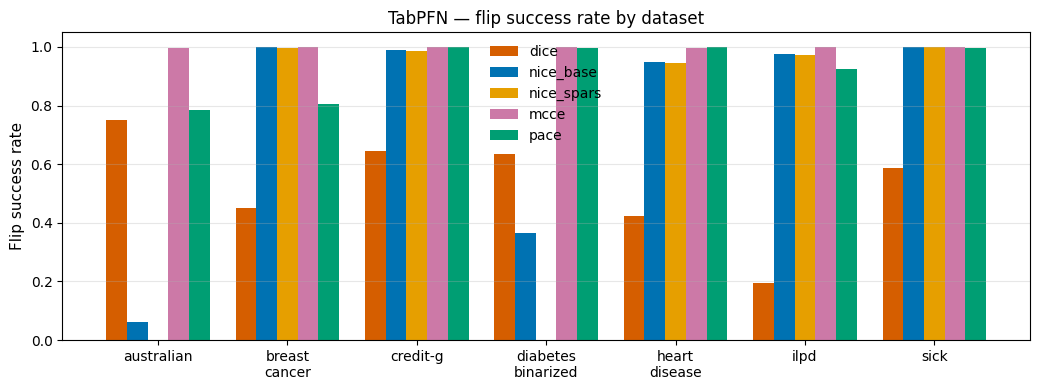

In [176]:

# Flip success rate for TabPFN only, split by dataset
tabpfn_df = df[df["model"] == "TabPFN"]
datasets_sorted = sorted(tabpfn_df["dataset"].unique())

rate_ds = tabpfn_df.groupby(["dataset", "method"], as_index=False)["flip_ok"].mean()

x = np.arange(len(datasets_sorted))
width = 0.8 / max(1, len(methods))

fig, ax = plt.subplots(figsize=(max(8, len(datasets_sorted) * 1.5), 4))
for i, method in enumerate(methods):
    vals = []
    for ds in datasets_sorted:
        sub = rate_ds[(rate_ds["dataset"] == ds) & (rate_ds["method"] == method)]
        vals.append(float(sub["flip_ok"].iloc[0]) if not sub.empty else 0.0)
    offset = (i - (len(methods) - 1) / 2) * width
    ax.bar(x + offset, vals, width, color=COLORS[method], label=method)

ax.set_xticks(x)
ax.set_xticklabels([ds.replace("_", "\n") for ds in datasets_sorted], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Flip success rate", fontsize=11)
ax.set_title("TabPFN — flip success rate by dataset", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=10)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.tick_params(axis="both", which="both", width=0.8, labelsize=10)
fig.tight_layout()
fig.savefig(data_in + "_flip_rate_tabpfn_by_dataset.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()


In [177]:
def make_paired_table(
    df: pd.DataFrame,
    *,
    methods=None,
    group_cols=("dataset", "model", "idx", "seed"),
    require_status_ok=True,
    status_col="status",
    ok_values=("ok",),
    metrics=("l0", "l2", "time_s", "flip_ok", "margin_cf", "p_cf", "p_f"),
    l0_as_int=True,
):
    """
    Convert long-form CF results into a paired wide table:
      one row per instance (dataset, model, idx, seed),
      columns like l0__pace, l2__pace, ... l0__nice, ...

    If require_status_ok=True, keeps only rows with status in ok_values per method.

    Returns: wide_df, methods_used, group_cols_used
    """
    df = df.copy()

    # Decide method set
    if methods is None:
        methods = sorted(df["method"].unique())
    else:
        methods = list(methods)

    # Ensure group columns exist (seed may be missing)
    group_cols = [c for c in group_cols if c in df.columns]
    if not group_cols:
        raise ValueError("No group_cols found in df. Need at least idx, preferably dataset+model+idx (+seed).")

    # Optional filter: only ok status rows
    if require_status_ok and (status_col in df.columns):
        df = df[df[status_col].isin(ok_values)].copy()

    # Keep only relevant methods
    df = df[df["method"].isin(methods)].copy()

    # Keep only required columns
    keep = list(dict.fromkeys(group_cols + ["method"] + [m for m in metrics if m in df.columns]))
    df = df[keep].copy()

    # If multiple rows per (group, method), keep the best/first deterministically
    df = df.sort_values(group_cols + ["method"])
    df = df.drop_duplicates(subset=group_cols + ["method"], keep="first")

    # Optionally make l0 integer-ish (l0 is float in df)
    if l0_as_int and "l0" in df.columns:
        df["l0"] = pd.to_numeric(df["l0"], errors="coerce")
        df["l0"] = df["l0"].round().astype("Int64")  # nullable int

    # Wide pivot for each metric
    wide_parts = []
    for col in [c for c in metrics if c in df.columns]:
        w = df.pivot(index=group_cols, columns="method", values=col)
        w.columns = [f"{col}__{m}" for m in w.columns]
        wide_parts.append(w)

    wide = pd.concat(wide_parts, axis=1).reset_index()

    # Determine which methods actually appear in wide
    methods_used = []
    for m in methods:
        if any(col.endswith(f"__{m}") for col in wide.columns):
            methods_used.append(m)

    return wide, methods_used, group_cols

# -----------------------------
# 1) Paired Pareto dominance
# -----------------------------
def pareto_dominance(
    wide: pd.DataFrame,
    *,
    method_a: str,
    method_b: str,
    l0_col="l0",
    l2_col="l2",
    require_nonmissing=True,
):
    """
    Compute Pareto dominance counts between method_a and method_b using paired rows.

    A dominates B if (l0_A <= l0_B) and (l2_A <= l2_B) with at least one strict.
    Likewise for B dominates A.

    Returns dict with counts and rates among comparable rows.
    """
    a_l0 = wide.get(f"{l0_col}__{method_a}")
    b_l0 = wide.get(f"{l0_col}__{method_b}")
    a_l2 = wide.get(f"{l2_col}__{method_a}")
    b_l2 = wide.get(f"{l2_col}__{method_b}")

    if a_l0 is None or b_l0 is None or a_l2 is None or b_l2 is None:
        raise ValueError("Missing needed columns in wide table for these methods/metrics.")

    mask = pd.Series(True, index=wide.index)
    if require_nonmissing:
        mask &= a_l0.notna() & b_l0.notna() & a_l2.notna() & b_l2.notna()

    A_l0 = a_l0[mask].astype(float).to_numpy()
    B_l0 = b_l0[mask].astype(float).to_numpy()
    A_l2 = a_l2[mask].astype(float).to_numpy()
    B_l2 = b_l2[mask].astype(float).to_numpy()

    # dominance logic
    A_le = (A_l0 <= B_l0) & (A_l2 <= B_l2)
    B_le = (B_l0 <= A_l0) & (B_l2 <= A_l2)
    equal = (A_l0 == B_l0) & (A_l2 == B_l2)

    A_dom = A_le & (~equal)
    B_dom = B_le & (~equal)
    incomparable = ~(A_dom | B_dom | equal)

    n = mask.sum()
    out = {
        "method_a": method_a,
        "method_b": method_b,
        "n_paired": int(n),
        "n_A_dom": int(A_dom.sum()),
        "n_B_dom": int(B_dom.sum()),
        "n_equal": int(equal.sum()),
        "n_incomparable": int(incomparable.sum()),
    }
    denom = max(1, out["n_A_dom"] + out["n_B_dom"]) #max(1, out["n_A_dom"] + out["n_B_dom"] + out["n_equal"] + out["n_incomparable"])
    out.update({
        "rate_A_dom": out["n_A_dom"] / denom,
        "rate_B_dom": out["n_B_dom"] / denom,
        "rate_equal": out["n_equal"] / denom,
        "rate_incomparable": out["n_incomparable"] / denom,
    })
    return out


def dominance_by_group(
    df: pd.DataFrame,
    *,
    method_a: str,
    method_b: str,
    group=("dataset", "model"),
    **paired_kwargs
):
    """
    Compute Pareto dominance for each (dataset, model) group.
    Returns a DataFrame of dominance stats.
    """
    wide, _, _ = make_paired_table(df, **paired_kwargs)
    group = [g for g in group if g in wide.columns]
    if not group:
        # no grouping possible -> single overall row
        return pd.DataFrame([pareto_dominance(wide, method_a=method_a, method_b=method_b)])

    rows = []
    for key, sub in wide.groupby(group, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        base = dict(zip(group, key))
        stats = pareto_dominance(sub, method_a=method_a, method_b=method_b)
        rows.append({**base, **stats})
    return pd.DataFrame(rows)


# Optional: bootstrap CI for dominance rate (A dominates B)
def bootstrap_dom_ci(
    wide: pd.DataFrame,
    *,
    method_a: str,
    method_b: str,
    n_boot=2000,
    alpha=0.05,
    random_state=0
):
    rng = np.random.default_rng(random_state)
    # Compute per-row dominance indicator among paired rows
    a_l0 = wide[f"l0__{method_a}"].astype(float)
    b_l0 = wide[f"l0__{method_b}"].astype(float)
    a_l2 = wide[f"l2__{method_a}"].astype(float)
    b_l2 = wide[f"l2__{method_b}"].astype(float)
    mask = a_l0.notna() & b_l0.notna() & a_l2.notna() & b_l2.notna()
    sub = wide.loc[mask].copy()
    if sub.empty:
        return {"rate": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": 0}

    A_dom = ((sub[f"l0__{method_a}"] <= sub[f"l0__{method_b}"]) &
             (sub[f"l2__{method_a}"] <= sub[f"l2__{method_b}"]) &
             ~((sub[f"l0__{method_a}"] == sub[f"l0__{method_b}"]) &
               (sub[f"l2__{method_a}"] == sub[f"l2__{method_b}"]))).to_numpy().astype(float)

    n = len(A_dom)
    rate = float(A_dom.mean())

    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots[b] = A_dom[idx].mean()

    lo = float(np.quantile(boots, alpha/2))
    hi = float(np.quantile(boots, 1 - alpha/2))
    return {"rate": rate, "ci_low": lo, "ci_high": hi, "n": n}

import numpy as np
import pandas as pd

try:
    from scipy.stats import wilcoxon
except Exception:
    wilcoxon = None


def _bootstrap_ci_median(delta: np.ndarray, *, n_boot: int = 2000, ci: float = 0.95, rng=None):
    """
    Bootstrap CI for the median of paired differences.
    Returns (ci_lo, ci_hi). Uses percentile bootstrap.
    """
    delta = np.asarray(delta, dtype=float)
    delta = delta[np.isfinite(delta)]
    n = delta.size
    if n == 0:
        return (np.nan, np.nan)
    if n == 1:
        # degenerate: CI collapses to the only observation
        return (float(delta[0]), float(delta[0]))

    if rng is None:
        rng = np.random.default_rng(0)

    idx = rng.integers(0, n, size=(n_boot, n))
    med = np.median(delta[idx], axis=1)

    alpha = (1.0 - ci) / 2.0
    lo = np.quantile(med, alpha)
    hi = np.quantile(med, 1.0 - alpha)
    return (float(lo), float(hi))


def conditional_l2_wilcoxon(
    df: pd.DataFrame,
    *,
    method_a: str,  # our method
    method_b: str,
    l0_values=None,
    min_n=20,
    group=("dataset", "model"),
    paired_kwargs=None,
    # --- new CI controls ---
    add_ci: bool = True,
    ci: float = 0.95,
    n_boot: int = 2000,
    random_state: int = 0,
):
    if wilcoxon is None:
        raise ImportError("scipy is required for Wilcoxon tests: pip install scipy")

    if paired_kwargs is None:
        paired_kwargs = {}

    wide, _, _ = make_paired_table(df, **paired_kwargs)

    group = [g for g in group if g in wide.columns]
    if not group:
        group = []

    # infer l0 values safely
    if l0_values is None:
        a_l0 = pd.to_numeric(wide.get(f"l0__{method_a}"), errors="coerce")
        b_l0 = pd.to_numeric(wide.get(f"l0__{method_b}"), errors="coerce")
        both = pd.concat([a_l0, b_l0], axis=1).stack().dropna()
        l0_values = sorted(pd.unique(both.round().astype(int)))

    rows = []
    grouped = [((), wide)] if not group else wide.groupby(group, dropna=False)

    # single RNG; spawn per-group to keep reproducible but stable across loops
    root_rng = np.random.default_rng(random_state)

    for key, sub in grouped:
        if group and not isinstance(key, tuple):
            key = (key,)
        base = dict(zip(group, key)) if group else {}

        # precompute numeric l0 columns once per group (fast + safe)
        a_l0 = pd.to_numeric(sub.get(f"l0__{method_a}"), errors="coerce").round()
        b_l0 = pd.to_numeric(sub.get(f"l0__{method_b}"), errors="coerce").round()

        # group-specific RNG (so results don't depend on l0_values order)
        rng = np.random.default_rng(root_rng.integers(0, 2**63 - 1))

        for k in l0_values:
            kk = float(k)

            m = (
                a_l0.notna()
                & b_l0.notna()
                & (a_l0 == kk)
                & (b_l0 == kk)
                & sub[f"l2__{method_a}"].notna()
                & sub[f"l2__{method_b}"].notna()
            )

            s = sub.loc[m, [f"l2__{method_a}", f"l2__{method_b}"]].astype(float)
            n = len(s)
            if n < min_n:
                continue

            delta = (s[f"l2__{method_a}"] - s[f"l2__{method_b}"]).to_numpy()

            # Wilcoxon (paired, two-sided)
            stat, p = wilcoxon(delta, zero_method="wilcox", alternative="two-sided")

            med = float(np.median(delta))

            row = {
                **base,
                "l0": int(k),
                "n": int(n),
                "median_delta_l2_A_minus_B": med,
                "wilcoxon_stat": float(stat),
                "p_value": float(p),
            }

            if add_ci:
                ci_lo, ci_hi = _bootstrap_ci_median(delta, n_boot=n_boot, ci=ci, rng=rng)
                row["ci_lo"] = ci_lo
                row["ci_hi"] = ci_hi

            rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        cols = list(group) + ["l0", "n", "median_delta_l2_A_minus_B", "wilcoxon_stat", "p_value"]
        if add_ci:
            cols += ["ci_lo", "ci_hi"]
        return pd.DataFrame(columns=cols)

    sort_cols = (list(group) + ["l0"]) if group else ["l0"]
    return out.sort_values(sort_cols).reset_index(drop=True)

# -----------------------------
# Run both analyses
# -----------------------------
def compare_methods(
    df: pd.DataFrame,
    *,
    method_a: str,
    method_b: str,
    paired_kwargs=None,
    min_n_per_l0=20,
):
    """
    Returns:
      - dominance_df: Pareto dominance per (dataset, model)
      - cond_df: conditional l2 Wilcoxon per (dataset, model, l0)
    """
    if paired_kwargs is None:
        paired_kwargs = {}

    dominance_df = dominance_by_group(
        df,
        method_a=method_a,
        method_b=method_b,
        **paired_kwargs
    )

    cond_df = conditional_l2_wilcoxon(
        df,
        method_a=method_a,
        method_b=method_b,
        min_n=min_n_per_l0,
        paired_kwargs=paired_kwargs
    )
    return dominance_df, cond_df

## 3. Pairwise Statistical Comparisons (PACE vs. each baseline)

For each pair (PACE, baseline), instances are **paired** on (dataset, model, idx, seed) and only rows where both methods succeeded are kept.

### 3a. Pareto dominance  
A solution A **dominates** B if ℓ₀(A) ≤ ℓ₀(B) **and** ℓ₂(A) ≤ ℓ₂(B) with at least one strict.  
Reported per (dataset, model): counts of A-dom, B-dom, tie, incomparable, and the dominance rate among decisive pairs.

### 3b. Conditional Wilcoxon on ℓ₂ | ℓ₀ = k  
For pairs where **both** methods changed exactly k features, runs a paired Wilcoxon signed-rank test on Δℓ₂ = ℓ₂(PACE) − ℓ₂(baseline).  
**Negative median** → PACE achieves smaller distance at the same sparsity level.  
Reports: median Δℓ₂, Wilcoxon W, p-value, and 95% bootstrap CI for the median (percentile bootstrap, 2000 resamples).

In [178]:
def export_wilcoxon_table_to_latex(df, filename):
    df2 = df.copy()

    # Escape underscores in dataset names only
    df2["dataset"] = df2["dataset"].str.replace("_", r"\_", regex=False)

    # Rename columns with LaTeX math
    df2 = df2.rename(columns={
        "l0": r"$\ell_0$",
        "median_delta_l2_A_minus_B": r"$\mathrm{median}\,\Delta\ell_2^{A-B}$",
        "wilcoxon_stat": r"$W$",
        "p_value": r"$p$-value",
        "ci_lo": r"CI$_{lo}$",
        "ci_hi": r"CI$_{hi}$"
    })

    latex_code = df2.to_latex(
        index=False,
        escape=False,        # keep math in headers
        float_format="%.3g",
        column_format="llrrrrrrr"
    )

    with open(filename, "w") as f:
        f.write(latex_code)

    print(f"LaTeX table written to {filename}")


In [179]:
paired_kwargs = dict(
    methods=["nice_base", "nice_spars", "dice", "mcce", "pace"],
    group_cols=("dataset", "model", "idx", "seed"),
    require_status_ok=True,
    ok_values=("ok",),
    metrics=("l0", "l2", "time_s", "flip_ok"),
    l0_as_int=True,
)

BASELINES = ["nice_base", "nice_spars", "mcce", "dice"]

dom = {}
cond = {}
for b in BASELINES:
    dom[b], cond[b] = compare_methods(
        df,
        method_a="pace",
        method_b=b,
        paired_kwargs=paired_kwargs,
        min_n_per_l0=5,
    )

print("Dominance (pace vs nice_spars):")
print(dom["nice_spars"])
print("\nConditional Wilcoxon (pace vs nice_spars):")
print(cond["nice_spars"].head(20))

Dominance (pace vs nice_spars):
               dataset   model method_a    method_b  n_paired  n_A_dom  \
0           australian      LR     pace  nice_spars       500      400   
1           australian      RF     pace  nice_spars         0        0   
2           australian  TabPFN     pace  nice_spars         0        0   
3           australian     XGB     pace  nice_spars       200      133   
4        breast_cancer      LR     pace  nice_spars       388       35   
5        breast_cancer      RF     pace  nice_spars       362       85   
6        breast_cancer  TabPFN     pace  nice_spars       401       87   
7        breast_cancer     XGB     pace  nice_spars       413       62   
8             credit-g      LR     pace  nice_spars       500      305   
9             credit-g      RF     pace  nice_spars       493      331   
10            credit-g  TabPFN     pace  nice_spars       493      316   
11            credit-g     XGB     pace  nice_spars       500      363   
12  di

In [180]:
#export_wilcoxon_table_to_latex(cond_df_dice, data_in+"_cond_dice.tex")
#export_wilcoxon_table_to_latex(cond_df_nice, data_in+"_cond_nice.tex")

In [181]:
from matplotlib import cm as _cm

def _l0_color(l0):
    """Blues for l0 1-4, Oranges for l0 5+. Both single-hue ramps = colorblind safe."""
    if l0 <= 4:
        t = np.clip((l0 - 1) / 3, 0, 1)
        return _cm.Blues(0.35 + 0.55 * t)
    else:
        t = np.clip((l0 - 5) / 3, 0, 1)
        return _cm.Oranges(0.35 + 0.55 * t)


def plot_conditional_wilcoxon(cond_dict):
    dfs = []
    for baseline, df_b in cond_dict.items():
        d = df_b.copy()
        d["comp"] = f"PACE − {baseline}"
        dfs.append(d)
    df = pd.concat(dfs, ignore_index=True)

    df["y_label"] = df["dataset"] + " – " + df["model"] + " (" + df["comp"] + ")"

    l0_vals = sorted(df["l0"].unique())

    # marker size proportional to sqrt(n)
    n_all = df["n"].to_numpy(dtype=float)
    n_min, n_max = n_all.min(), n_all.max()
    def _sz(n, lo=30, hi=250):
        if n_max == n_min:
            return (lo + hi) / 2
        return lo + (hi - lo) * np.sqrt((n - n_min) / (n_max - n_min))

    LOW_N = 15

    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(10, max(6, len(df) * 0.35)))

    for i, row in df.iterrows():
        color = _l0_color(row["l0"])
        med = row["median_delta_l2_A_minus_B"]
        ax.errorbar(
            med, i,
            xerr=[[med - row["ci_lo"]], [row["ci_hi"] - med]],
            fmt="none", color=color, capsize=3, alpha=0.8,
        )
        ax.scatter(med, i, s=_sz(row["n"]), color=color, zorder=5,
                   edgecolors="black" if row["n"] < LOW_N else "none",
                   linewidths=0.8)

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(df["y_label"], fontsize=11)
    ax.set_xlabel(r"Median paired difference in $\ell_2 \mid \ell_0$", fontsize=11)
    ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)

    legend_elems = []
    for l0 in l0_vals:
        legend_elems.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=_l0_color(l0),
                   markersize=8, label=rf"$\ell_0={l0}$")
        )
    for ref_n in [10, 50, 200]:
        legend_elems.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
                   markersize=np.sqrt(_sz(min(ref_n, n_max))), label=f"n={ref_n}")
        )
    legend_elems.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
               markeredgecolor="black", markeredgewidth=0.8, markersize=7,
               label=f"n < {LOW_N} (low)")
    )
    ax.legend(handles=legend_elems, title="Sparsity / n", frameon=False)

    plt.tight_layout()
    plt.savefig(data_in + "_cond_l2_diff.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


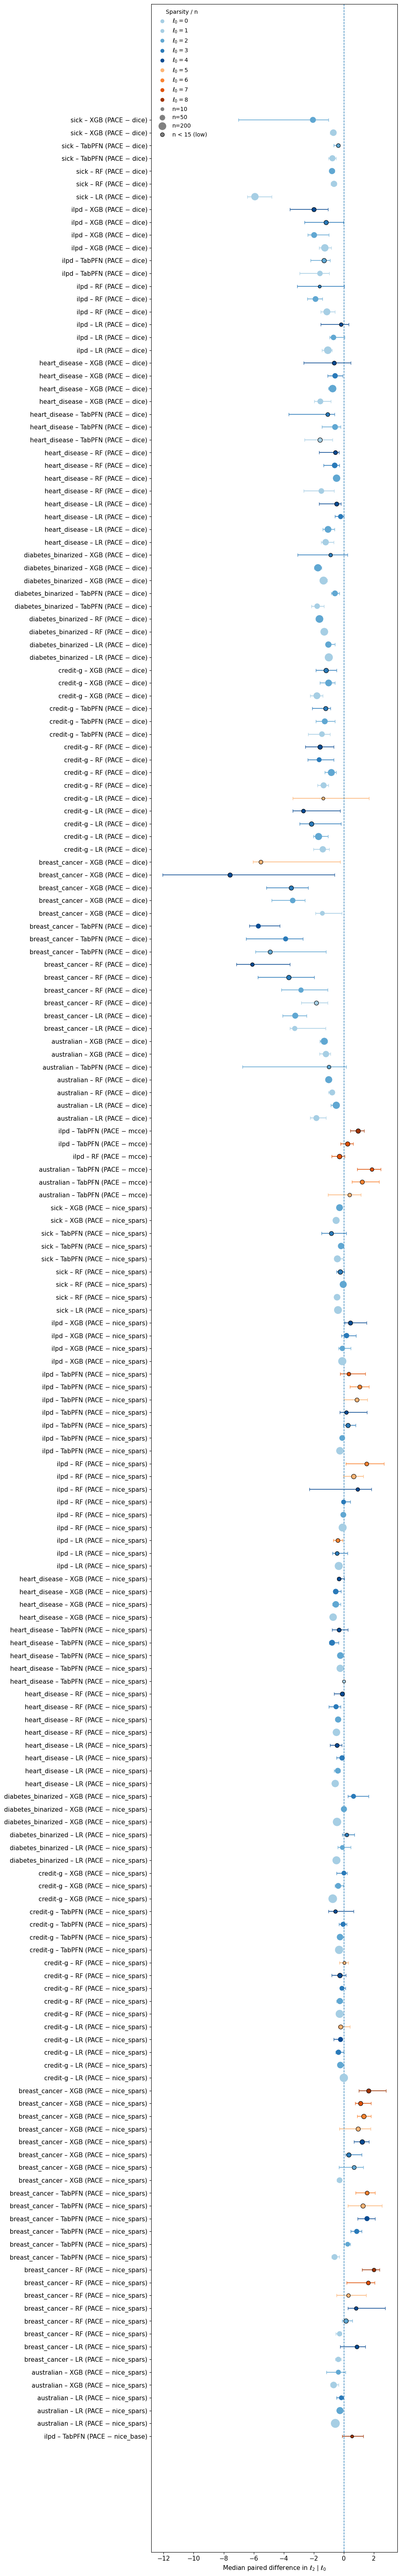

In [182]:
if data_in == "real":
    plot_conditional_wilcoxon(cond)

## 4. Conditional ℓ₂ Difference Plot

Forest plot of the median paired Δℓ₂ at each ℓ₀ level, with 95% bootstrap CI.  
A point **left of zero** means PACE has smaller ℓ₂ at that sparsity level.

### Aggregated across datasets  
Points show the n-weighted mean of per-dataset medians; CIs are bootstrap-resampled over datasets.  
One row per (model, comparison, ℓ₀ value).

In [191]:
def _agg_bootstrap_group(g: pd.DataFrame, B: int = 2000, seed: int = 0):
    rng = np.random.default_rng(seed)
    x = g["median_delta_l2_A_minus_B"].to_numpy(dtype=float)
    w = g["n"].to_numpy(dtype=float)

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    if np.all(w == 0):
        w = np.ones_like(w)

    point = float(np.average(x, weights=w))
    if len(x) == 1:
        return point, point, point, int(w.sum())

    idx = np.arange(len(x))
    boots = np.empty(B, dtype=float)
    for b in range(B):
        samp = rng.choice(idx, size=len(idx), replace=True)
        boots[b] = np.average(x[samp], weights=w[samp])

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, float(lo), float(hi), int(w.sum())


def plot_conditional_wilcoxon_aggregated(cond_dict, outpath, B=2000, seed=0):
    dfs = []
    for baseline, df_b in cond_dict.items():
        d = df_b.copy()
        d["comp"] = f"PACE − {baseline}"
        dfs.append(d)
    df = pd.concat(dfs, ignore_index=True)

    rows = []
    for (model, comp, l0), g in df.groupby(["model", "comp", "l0"], sort=True):
        point, lo, hi, n_total = _agg_bootstrap_group(g, B=B, seed=seed)
        rows.append({
            "model": model, "comp": comp, "l0": int(l0),
            "median_delta": point, "ci_lo": lo, "ci_hi": hi,
            "n_total": n_total, "k_datasets": len(g),
        })
    agg = pd.DataFrame(rows)

    agg["y_label"] = agg["model"] + " (" + agg["comp"] + ")"
    order = agg[["y_label"]].drop_duplicates()["y_label"].tolist()
    y_map = {lab: i for i, lab in enumerate(order)}
    agg["y"] = agg["y_label"].map(y_map)

    l0_vals = sorted(agg["l0"].unique())

    # marker size proportional to sqrt(n_total)
    n_all = agg["n_total"].to_numpy(dtype=float)
    n_min, n_max = n_all.min(), n_all.max()
    def _sz(n, lo=30, hi=300):
        if n_max == n_min:
            return (lo + hi) / 2
        return lo + (hi - lo) * np.sqrt((n - n_min) / (n_max - n_min))

    LOW_N = 30

    fig, ax = plt.subplots(figsize=(8, max(6, len(order) * 0.5)))

    for _, r in agg.sort_values(["y", "l0"]).iterrows():
        x = r["median_delta"]
        y = r["y"]
        color = _l0_color(r["l0"])
        ax.errorbar(x, y, xerr=[[x - r["ci_lo"]], [r["ci_hi"] - x]],
                    fmt="none", capsize=3, color=color, alpha=0.8)
        ax.scatter(x, y, s=_sz(r["n_total"]), color=color, zorder=5,
                   edgecolors="black" if r["n_total"] < LOW_N else "none",
                   linewidths=0.8)

    ax.axvline(0, linestyle="--", linewidth=1,color='black')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=11)
    ax.set_xlabel(r"Aggregated median paired difference in $\ell_2 \mid \ell_0$", fontsize=11)
    ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)

    legend_elems = []
    for l0 in l0_vals:
        legend_elems.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=_l0_color(l0),
                   markersize=8, label=rf"$\ell_0={l0}$")
        )
    for ref_n in [30, 200, 1000]:
        legend_elems.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
                   markersize=np.sqrt(_sz(min(ref_n, n_max))), label=f"n={ref_n}")
        )
    legend_elems.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
               markeredgecolor="black", markeredgewidth=0.8, markersize=7,
               label=f"n < {LOW_N} (low)")
    )
    ax.legend(handles=legend_elems, title="Sparsity / n", frameon=False)
    plt.tight_layout()
    plt.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")

    return agg


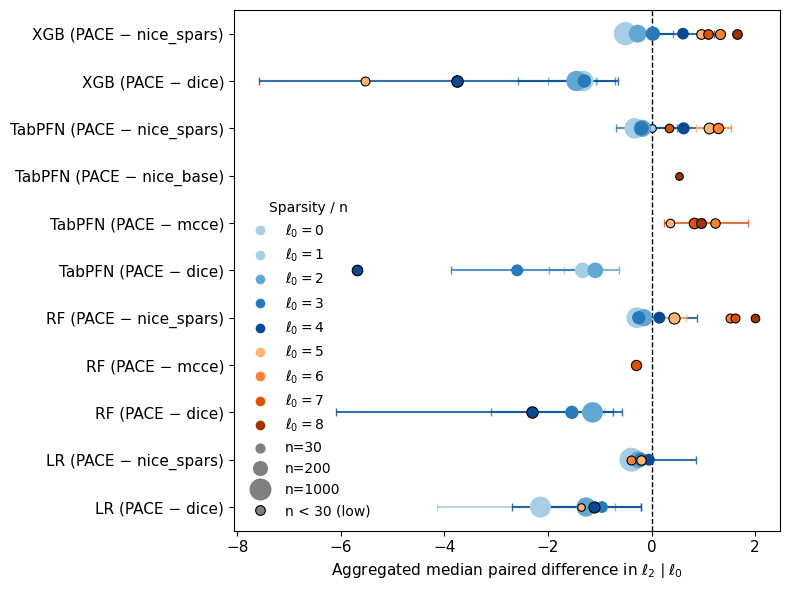

In [192]:
agg = plot_conditional_wilcoxon_aggregated(
    cond,
    outpath=data_in + "_cond_l2_diff_AGG.pdf",
    B=3000,
    seed=0
)

Here's a caption for the per-dataset forest plot:

Figure X. Conditional ℓ₂ comparison between PACE and each baseline at matched sparsity levels.
Each row shows the median paired difference in Euclidean distance (Δℓ₂ = ℓ₂(PACE) − ℓ₂(baseline)) for counterfactuals where both methods achieved exactly the same number of feature changes (ℓ₀ = k), evaluated on the same factual instance. A negative value indicates that PACE produces a closer counterfactual at equal sparsity. Error bars are 95% bootstrap confidence intervals for the median (2 000 resamples). Dot colour encodes the sparsity level: blue shades for ℓ₀ ∈ {1, 2, 3, 4} and orange shades for ℓ₀ ∈ {5, 6, 7, 8}, with darker shades indicating higher ℓ₀ within each group. Dot area is proportional to the number of paired instances n contributing to the test; dots with a black outline (n < 15) should be interpreted with caution as the paired sample is small, which may reflect that the baseline rarely achieves that sparsity level.

And for the aggregated version:

Figure X. Aggregated conditional ℓ₂ comparison (PACE vs. baselines), pooled across datasets.
As above, but median Δℓ₂ values are aggregated across datasets using an n-weighted mean, with 95% bootstrap confidence intervals resampled over datasets. One row per (model, comparison, ℓ₀) combination. Dot area is proportional to the total number of paired instances n across all datasets; dots with a black outline (n < 30) indicate sparse coverage and should be interpreted with caution.

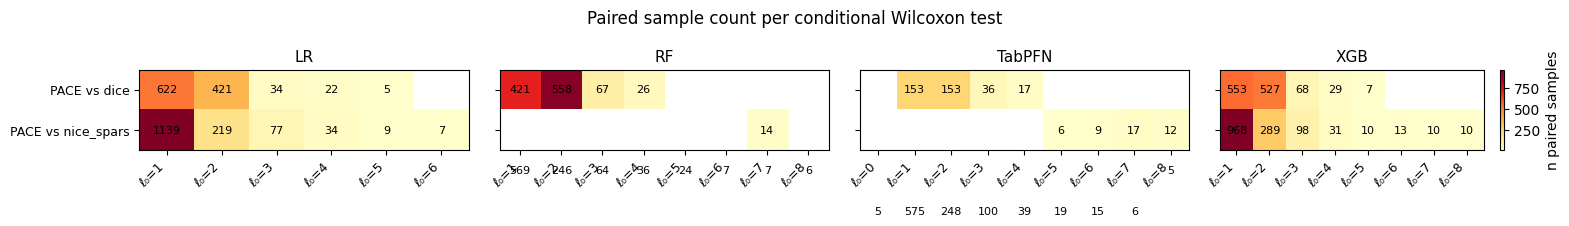

In [185]:
# ℓ₀ coverage heatmap: how many paired samples feed each conditional test
# Rows = comparison (PACE vs baseline), columns = ℓ₀, values = n paired instances.
# Small n → test result is unreliable. Black outline in forest plots = n < LOW_N.

dfs = []
for baseline, df_b in cond.items():
    dfs.append(df_b.assign(comp=f"PACE vs {baseline}"))
cond_all = pd.concat(dfs, ignore_index=True)

models_list = sorted(cond_all["model"].unique())
n_models = len(models_list)

fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models_list):
    sub = cond_all[cond_all["model"] == model]
    pivot = sub.pivot_table(index="comp", columns="l0", values="n", aggfunc="sum")
    pivot = pivot.reindex(columns=sorted(pivot.columns))

    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"ℓ₀={k}" for k in pivot.columns], rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    if ax == axes[0]:
        ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(model, fontsize=11)

    # annotate each cell with its count
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, str(int(val)), ha="center", va="center",
                        fontsize=8, color="black" if val > pivot.values.max() * 0.5 else "black")

plt.colorbar(im, ax=axes[-1], label="n paired samples")
fig.suptitle("Paired sample count per conditional Wilcoxon test", fontsize=12)
fig.patch.set_facecolor("white")
fig.tight_layout()
fig.savefig(data_in + "_cond_coverage.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.show()


In [186]:
#cond_df_mcce[cond_df_mcce.l0==1]

In [187]:
#export_table_to_latex(dom_df_dice, data_in+"_pareto_dom_pace_dice.tex")
#export_table_to_latex(dom_df_nice, data_in+"_pareto_dom_pace_nice.tex")

In [188]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return center - half, center + half


def plot_pareto_dominance_real(dom_dict, title=None, outpath=None, seed=0):
    rng = np.random.default_rng(seed)

    dfs = []
    for baseline, df_b in dom_dict.items():
        dfs.append(df_b.assign(comp=f"PACE vs {baseline}"))
    df = pd.concat(dfs, ignore_index=True)

    df["n_dec"] = df["n_A_dom"] + df["n_B_dom"]
    df = df[df["n_dec"] > 0].copy()

    cis = df.apply(lambda r: wilson_ci(int(r["n_A_dom"]), int(r["n_dec"])), axis=1)
    df["ci_lo"] = [c[0] for c in cis]
    df["ci_hi"] = [c[1] for c in cis]
    df["ci_lo"] = df["ci_lo"].clip(0.0, 1.0)
    df["ci_hi"] = df["ci_hi"].clip(0.0, 1.0)

    models_list = sorted(df["model"].unique())
    comps = [f"PACE vs {b}" for b in dom_dict]
    comp_colors = {f"PACE vs {b}": COLORS[b] for b in dom_dict}

    x = np.arange(len(models_list))
    width = 0.7 / max(len(comps), 1)
    jitter = 0.04

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.axhline(0.5, linestyle="--", linewidth=1)

    for j, comp in enumerate(comps):
        subc = df[df["comp"] == comp]
        for i, m in enumerate(models_list):
            sub = subc[subc["model"] == m]
            if sub.empty:
                continue
            x0 = x[i] + (j - (len(comps) - 1) / 2) * width
            for _, r in sub.iterrows():
                xi = x0 + rng.uniform(-jitter, jitter)
                y = r["rate_A_dom"]
                lo, hi = r["ci_lo"], r["ci_hi"]
                ax.errorbar(
                    xi, y,
                    yerr=[[y - lo], [hi - y]],
                    fmt=marker_map[r["dataset"]],
                    markersize=7, capsize=2,
                    color=comp_colors[comp],
                    ecolor=comp_colors[comp],
                    alpha=0.9
                )

    dataset_handles = [
        Line2D([0], [0], marker=marker_map[ds], linestyle="None",
               color="black", markersize=7, label=ds)
        for ds in datasets
    ]
    comp_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=comp_colors[c], label=c)
        for c in comps
    ]
    ax.legend(handles=comp_handles + dataset_handles, frameon=False,
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("PACE dominance rate")
    if title:
        ax.set_title(title)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.grid(True, axis="y", linewidth=0.5, alpha=0.6, color="black")
    ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [189]:
def plot_pareto_dominance_avg(dom_dict, title=None, outpath=None, baseline=0.5):
    dfs = []
    for b, df_b in dom_dict.items():
        dfs.append(df_b.assign(comp=f"PACE vs {b}"))
    df = pd.concat(dfs, ignore_index=True)

    df = df.assign(n_dec=df["n_A_dom"] + df["n_B_dom"]).query("n_dec > 0")

    agg = (df.groupby(["model", "comp"], as_index=False)
             .agg(n_A_dom=("n_A_dom", "sum"), n_dec=("n_dec", "sum")))
    agg["rate"] = agg["n_A_dom"] / agg["n_dec"]

    ci = agg.apply(lambda r: wilson_ci(int(r["n_A_dom"]), int(r["n_dec"])), axis=1)
    agg[["ci_lo", "ci_hi"]] = pd.DataFrame(ci.tolist(), index=agg.index).clip(0.0, 1.0)
    agg["err_lo"] = (agg["rate"] - agg["ci_lo"]).clip(lower=0.0)
    agg["err_hi"] = (agg["ci_hi"] - agg["rate"]).clip(lower=0.0)

    models_list = sorted(agg["model"].unique())
    comps = [f"PACE vs {b}" for b in dom_dict]
    comp_colors = {f"PACE vs {b}": COLORS[b] for b in dom_dict}

    x = np.arange(len(models_list))
    width = 0.7 / max(len(comps), 1)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axhline(baseline, linestyle="--", linewidth=1)

    for j, comp in enumerate(comps):
        sub = agg[agg["comp"] == comp].set_index("model").reindex(models_list)
        if sub.isna().all().all():
            continue
        y = sub["rate"].to_numpy(dtype=float)
        lo = sub["err_lo"].to_numpy(dtype=float)
        hi = sub["err_hi"].to_numpy(dtype=float)
        xpos = x + (j - (len(comps) - 1) / 2) * width
        ax.errorbar(
            xpos, y, yerr=[lo, hi],
            fmt="o", capsize=4, markersize=9, linewidth=1.2,
            color=comp_colors[comp], ecolor=comp_colors[comp],
            label=comp
        )

    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("PACE dominance rate (micro-avg over datasets)")
    if title:
        ax.set_title(title)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.grid(True, axis="y", linewidth=0.5, alpha=0.6, color="black")
    ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
    ax.legend(frameon=False)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

    return agg

## 5. Pareto Dominance Plot

Visual summary of dominance counts from section 3a.  
- **Real datasets**: per-(dataset, model) grouped bars with Wilson 95% CI.  
- **Mock datasets**: micro-averaged counts across all datasets per model.  

A binomial test (or the Wilson CI not crossing 0.5) indicates whether PACE dominates significantly more often than the baseline does.

ValueError: 'yerr' must not contain negative values

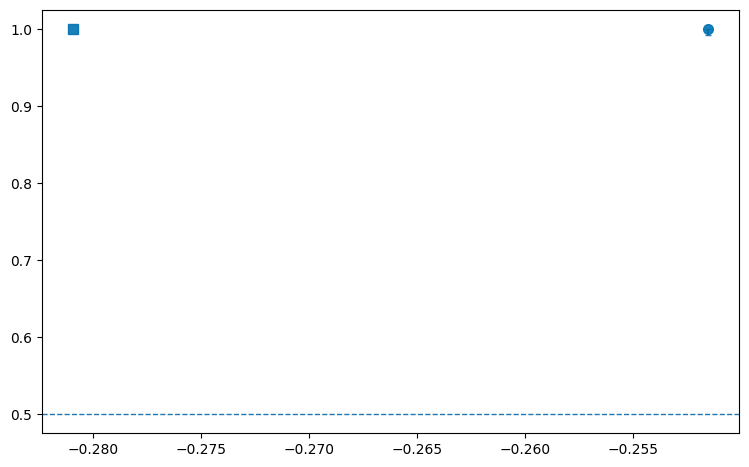

In [190]:
if data_in == "real":
    plot_pareto_dominance_real(dom, outpath=data_in + "_pareto.pdf")
elif data_in == "mock":
    plot_pareto_dominance_avg(dom, outpath=data_in + "_pareto.pdf")

In [ ]:
# Proposal type split for PACE
# best_source is stored inside the rep dict for each accepted PACE counterfactual
SOURCES = ["anchor_mix", "boundary_mix", "guided_noise"]

pace_ok = df[(df["method"] == "pace") & (df["status"] == "ok")].copy()
pace_ok["best_source"] = pace_ok["rep"].apply(
    lambda r: r.get("best_source") if isinstance(r, dict) else None
)
pace_ok = pace_ok.dropna(subset=["best_source"])

def source_split(sub):
    total = len(sub)
    row = {"n": total}
    for s in SOURCES:
        cnt = (sub["best_source"] == s).sum()
        row[s] = cnt
        row[f"{s}_pct"] = cnt / total if total > 0 else float("nan")
    return pd.Series(row)

# Overall
overall = source_split(pace_ok)
print("=== Overall proposal split (PACE, status=ok) ===")
print(f"  Total CFs: {int(overall['n'])}")
for s in SOURCES:
    print(f"  {s:14s}: {int(overall[s]):5d}  ({overall[s+'_pct']:.1%})")

# By dataset × model
by_group = pace_ok.groupby(["dataset", "model"]).apply(source_split).reset_index()

# Build a clean display table: pct columns only
pct_cols = [s + "_pct" for s in SOURCES]
display_tbl = by_group[["dataset", "model", "n"] + SOURCES + pct_cols].copy()
for s in SOURCES:
    display_tbl[s] = display_tbl.apply(
        lambda r: f"{int(r[s])} ({r[s+'_pct']:.0%})", axis=1
    )
display_tbl = display_tbl[["dataset", "model", "n"] + SOURCES].rename(
    columns={"n": "N", "anchor_mix": "anchor_mix (n, %)",
             "boundary_mix": "boundary_mix (n, %)", "guided_noise": "guided_noise (n, %)"}
)
display(display_tbl)


=== Overall proposal split (PACE, status=ok) ===
  Total CFs: 12124
  anchor_mix    :  8351  (68.9%)
  boundary_mix  :  3139  (25.9%)
  guided_noise  :   634  (5.2%)


/tmp/ipykernel_1405638/3083555950.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_group = pace_ok.groupby(["dataset", "model"]).apply(source_split).reset_index()


,dataset,model,N,"anchor_mix (n, %)","boundary_mix (n, %)","guided_noise (n, %)"
0,australian,LR,500.0,374 (75%),119 (24%),7 (1%)
1,australian,RF,500.0,342 (68%),143 (29%),15 (3%)
2,australian,TabPFN,393.0,359 (91%),26 (7%),8 (2%)
3,australian,XGB,500.0,226 (45%),180 (36%),94 (19%)
4,breast_cancer,LR,388.0,357 (92%),31 (8%),0 (0%)
5,breast_cancer,RF,388.0,320 (82%),61 (16%),7 (2%)
6,breast_cancer,TabPFN,402.0,304 (76%),85 (21%),13 (3%)
7,breast_cancer,XGB,413.0,334 (81%),75 (18%),4 (1%)
8,credit-g,LR,500.0,357 (71%),119 (24%),24 (5%)
9,credit-g,RF,500.0,366 (73%),100 (20%),34 (7%)
